In [9]:
from tasks import *
from PIL import Image

In [ ]:
keys = [
    (Metric.FID, 'itd'),
    (Metric.FID, 'aid'),
    (Metric.IF, 'itd'),
    (Metric.RANDOM, 'itd'),
]
d_filename = {
    (Metric.FID, 'itd'): 'fid_itd',
    (Metric.FID, 'aid'): 'fid_aid',
    (Metric.RANDOM, 'itd'): 'random',
    (Metric.IF, 'itd'): 'if',
}
d_metric_rename = {
    (Metric.FID, 'itd'): 'Influence on FID by ITD (Ours)',
    (Metric.FID, 'aid'): 'Influence on FID by AID (Ours)',
    (Metric.RANDOM, 'itd'): 'Random',
    (Metric.IF, 'itd'): 'Isolation Forest',
}

from_epochs = [49, 0]
name_metrics_infl = [Metric.FID, Metric.FID,  Metric.IF, Metric.RANDOM]
methods_influence = ['itd', 'aid', 'itd', 'itd']
scales_list = [[0.01, 0.001], [0.001, 0.001], [0.01, 0.001],  [0.001, 0.001]]
removal_rates = [0.001,0.002,0.005,0.01,0.02,0.05,0.1,0.2,0.5,0.7,0.9] 
n_epochs = 50
name_metric_eval = Metric.FID
config_base = {
    "from_epochs": from_epochs,
    "depth": 1000,
    "accumulate_decay": 0.999,
    "on_averaged_G": True,
    "dataset_split_infl": "valid",
    "dataset_split_eval": "test",
    "mixing": True,
    "rank_D": 32,
    "rank_G": 32,
    "removal_rates": removal_rates,
    "n_epochs": n_epochs,
    "to_epoch": n_epochs,
    "workspace_directory": "./.processed",
}

tasks = []
for name_metric_infl, scales, method_influence in zip(name_metrics_infl, scales_list, methods_influence):
    config = config_base.copy()
    config["scales"] = scales
    config["name_metric_infl"] = name_metric_infl
    config["name_metric_eval"] = name_metric_eval
    config["method_influence"] = method_influence 
    task = PipelineCleansing(**config)
    tasks.append(task)


In [26]:
task_dataset = tasks[0].clone(MakeDatasets)
d_dataset = task_dataset.output().load()
dataset = d_dataset['train']

In [ ]:
d_gen = {}
for j, (task, name_metric_infl, scales, method_influence) in enumerate(zip(tasks, name_metrics_infl, scales_list, methods_influence)):
    result_plot, results_plot_cleansing, results_infl_instance, result_eval_ori, results_eval_clean, result_gen_ori, results_gen_clean, resultss_eval_valid, resultss_eval_test = task.output().load()
    d_gen[(name_metric_infl, method_influence)] = results_infl_instance

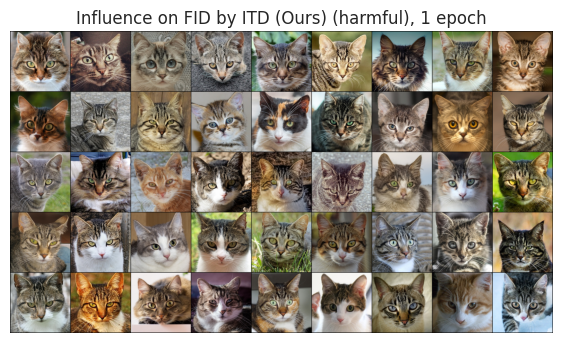

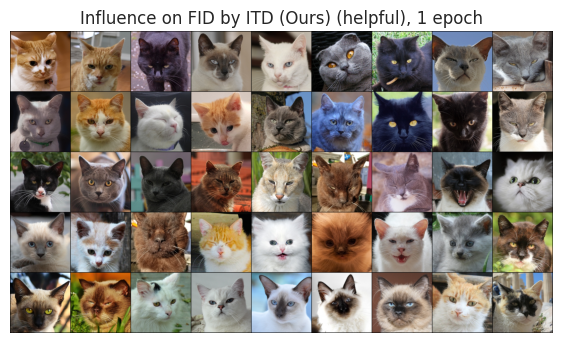

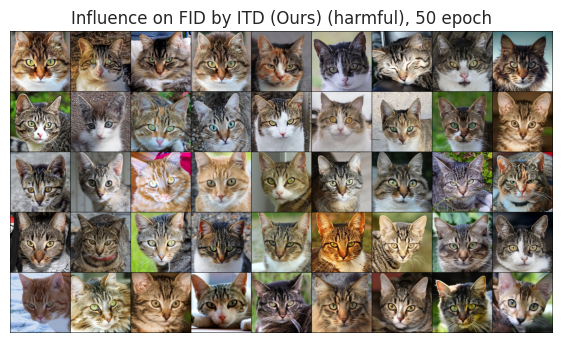

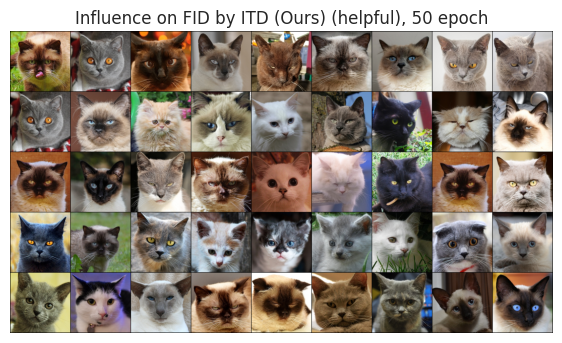

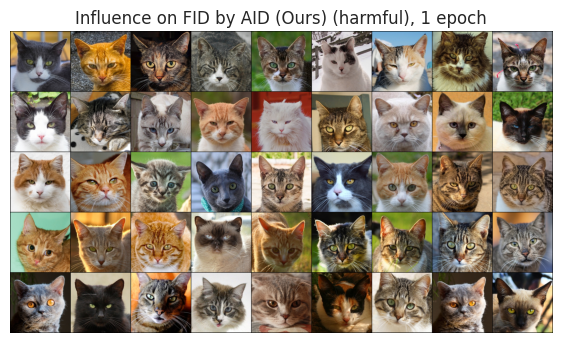

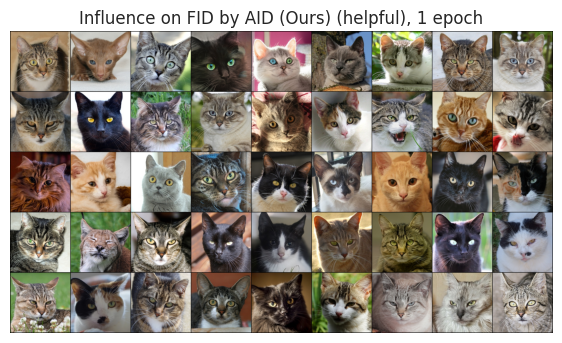

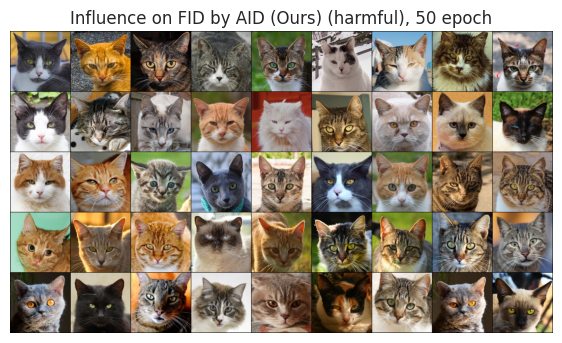

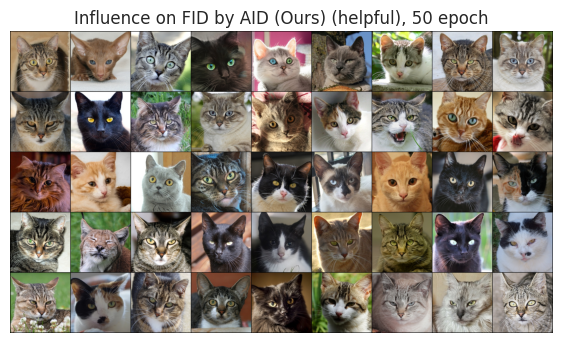

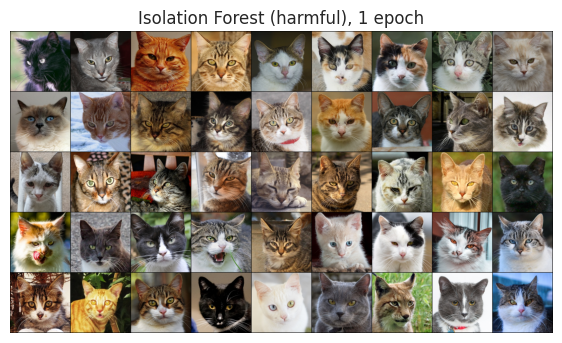

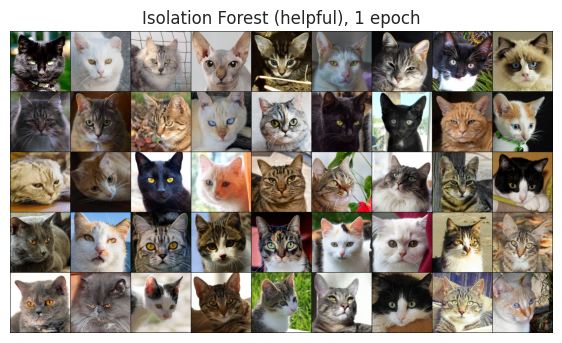

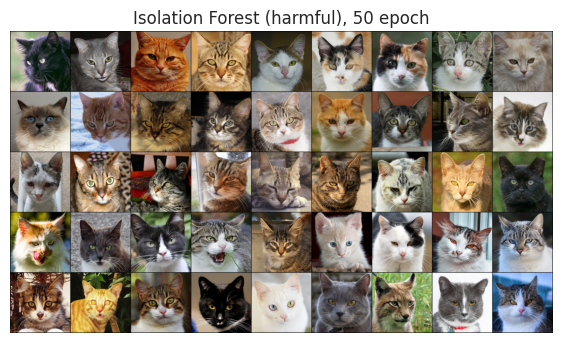

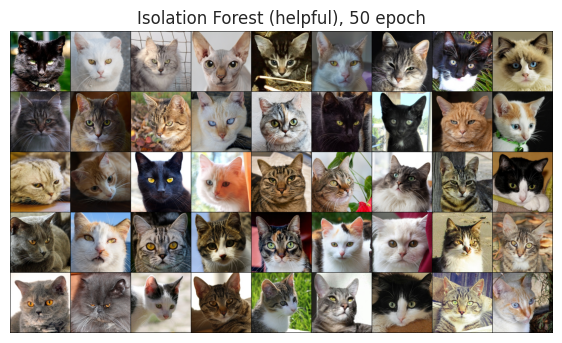

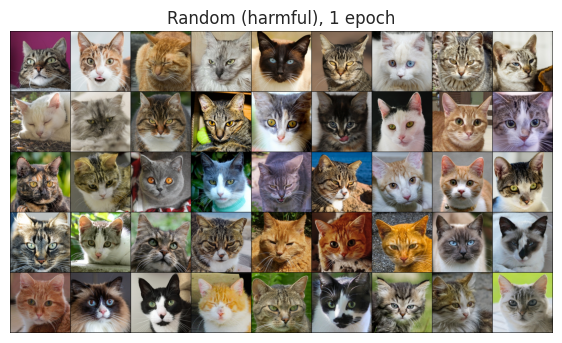

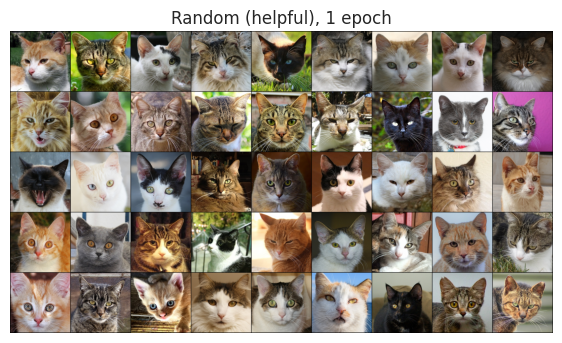

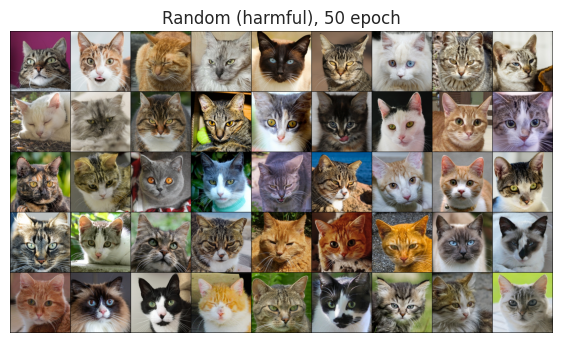

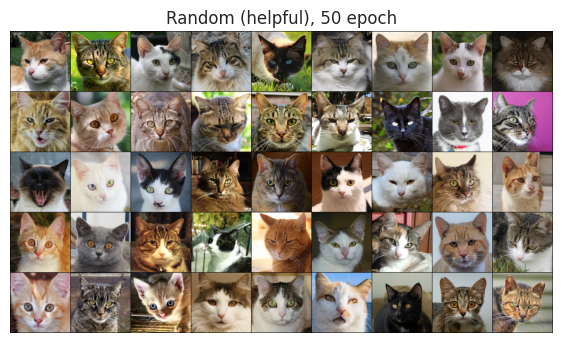

In [ ]:
grid = (5, 9)
image_cats = []
for key in keys:
    results_infl_instance = d_gen[key]
    for from_epoch, d_idxs in zip(from_epochs, results_infl_instance):
        for label, idxs in d_idxs.items():
            infl_images = [] 
            for idx in idxs:
                infl_images.append(dataset[idx][1].unsqueeze(0))
            infl_images_cat = torch.cat(infl_images, dim=0)[:grid[0]*grid[1]]
            utils.save_image(infl_images_cat, f'resources/tmp/app_{d_filename[key]}_{n_epochs-from_epoch}epoch_{label}.png', nrow=grid[1], normalize=True, value_range=(-1, 1))

            # load png file and plot image
            img = Image.open(f'resources/tmp/app_{d_filename[key]}_{n_epochs-from_epoch}epoch_{label}.png')
            plt.figure(figsize=(7, 4))
            plt.imshow(img)
            plt.axis('off')
            plt.title(f"{d_metric_rename[key]} ({label}), {n_epochs-from_epoch} epoch")
            plt.show()
